In [ ]:
# imports
import numpy as np

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [156]:
# constants

Q = 100 # dispersion constant
u = 1 # wind speed
H = 0 # height 

ay, by = 0.5, 0.92
az, bz = 0.5, 0.87

In [157]:
# loss function
def euclidean_distance_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.reduce_mean(tf.sqrt(tf.reduce_sum(tf.square(y_true - y_pred), axis=1) + 1e-6))

def calculate_3d_error(predictions, true_values):
    return np.linalg.norm(predictions - true_values, axis=1)

In [165]:
# generating data

def plume_function(x0, y0, z0, x, y, z):
    dx = max(x - x0, 0.0001)
    dy = max(y - y0, 0.0001)
    dz = max(z - z0, 0.0001)

    s_y = ay * dx**by
    s_z = az * dx**bz
    s_y = max(s_y, 0.00002)
    s_z = max(s_z, 0.00002)

    term1 = Q / (2 * np.pi * s_y * s_z * u)
    term2 = np.exp(-dy**2 / (2 * s_y**2))
    term3 = np.exp(-(dz - H)**2 / (2 * s_z**2))
    c = term1 * term2 * term3
    c = min(c, 300)
    return c


def generate_3_points_on_sphere(source, radius):
    source = np.array(source)
    points = []

    for _ in range(3):
        # Random spherical coordinates
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.arccos(np.random.uniform(-1, 1))

        # Spherical to Cartesian
        x = radius * np.sin(phi) * np.cos(theta)
        y = radius * np.sin(phi) * np.sin(theta)
        z = radius * np.cos(phi)

        # Shift by source position
        point = source + np.array([x, y, z])
        points.append(point)

    return np.array(points)


def generate_data(n_samples=10000):
    X, Y = [], []

    for _ in range(n_samples):
        x0, y0, z0 = np.random.uniform(0, 5, 3)
        source = [x0, y0, z0]

        radi = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 2, 3, 4, 5]
        
        total_samples = int(100/len(radi))
        sample = []
        for _ in range(total_samples):
            for r in radi:
                concentrations_drone = []
                drone_points = generate_3_points_on_sphere(source, r).tolist()
                # a = input()
                for drone in drone_points:
                    x, y, z = drone
                    c = plume_function(x0, y0, z0, x, y, z)
                    concentrations_drone.append(c)
                
                for index in range(3):
                    drone_points[index].append(concentrations_drone[index])
                sample.append(drone_points)
        X.append(sample)
        Y.append([x0, y0, z0])
        
    return np.array(X), np.array(Y)

In [166]:
# get data
X_train, Y_train = generate_data(100)
X_val, Y_val = generate_data(100)

In [167]:
print(len(X_train)) # 100
print(len(X_train[0])) # 100
print(len(X_train[0][0])) # 3
print(len(X_train[0][0][0])) # 4

100
100
3
4


In [168]:
X_train_reshaped = X_train.reshape((X_train.shape[0], 100, 3 * 4))

In [169]:
# build LSTM
source = keras.Sequential([
    layers.LSTM(16, return_sequences=True, input_shape=(100, 12)),
    layers.LSTM(8),
    layers.Dense(32, activation='relu'),
    layers.Dense(3),  # 3 * 4 = 12
])

# compile model using adam optimizer and euclidean distance as a loss function
source.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss=euclidean_distance_loss)

# Train the model
history = source.fit(X_train_reshaped, Y_train, epochs=81, batch_size=100, verbose=1)

Epoch 1/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 4.7212
Epoch 2/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7192
Epoch 3/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.7172
Epoch 4/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.7152
Epoch 5/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7132
Epoch 6/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.7112
Epoch 7/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.7092
Epoch 8/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 4.7071
Epoch 9/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.7051
Epoch 10/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7031
Epoch 11/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.7012
Epoch 12/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.6992
Epoch 13/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 4.6972
Epoch 14/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 4.6952
Epoch 15/81
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 4.6932
Epoch 16/81
1/1 ━━━━━━━━━━━━━━━━━━━━

In [183]:
# Give in source number
def point_spread(dataset_x, dataset_y, height_slice, point=0):
    allPoints = dataset_x[point]
    x_points = []
    y_points = []
    z_points = []
    concentrations = []

    for points in allPoints:       # points shape: (3, 4) per timestep probably
        for drone in points:
            x_points.append(drone[0])
            y_points.append(drone[1])
            z_points.append(drone[2])
            concentrations.append(drone[3])

    print("Actual Source: ", dataset_y[point])
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.hist(x_points, bins=50, color='red', edgecolor='black')
    plt.xlabel('X')
    plt.ylabel('Frequency')
    plt.title('X Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 2)
    plt.hist(y_points, bins=50, color='green', edgecolor='black')
    plt.xlabel('Y')
    plt.title('Y Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 3)
    plt.hist(z_points, bins=50, color='blue', edgecolor='black')
    plt.xlabel('Z')
    plt.title('Z Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 4)
    plt.hist(concentrations, bins=50, color='skyblue', edgecolor='black')
    plt.xlabel('Concentration')
    plt.title('Concentration Distribution')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # Grid
    x_range = np.linspace(0, 10, 10)    # downwind
    y_range = np.linspace(0, 10, 10)    # lateral
    z_plane = height_slice                           # fixed height cross-section

    # Evaluate on cross-section at z
    X, Y = np.meshgrid(x_range, y_range, indexing='ij')
    Z = np.full_like(X, z_plane)
    C = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            C[i, j] = plume_function(dataset_y[point][0], dataset_y[point][1], dataset_y[point][2], X[i, j], Y[i, j], Z[i, j])

    plt.contourf(X, Y, C, levels=50, cmap='inferno')
    plt.colorbar(label='Concentration')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'Pollution at z={z_plane}')
    plt.show()


Actual Source:  [2.18369902 2.99605792 2.2872117 ]


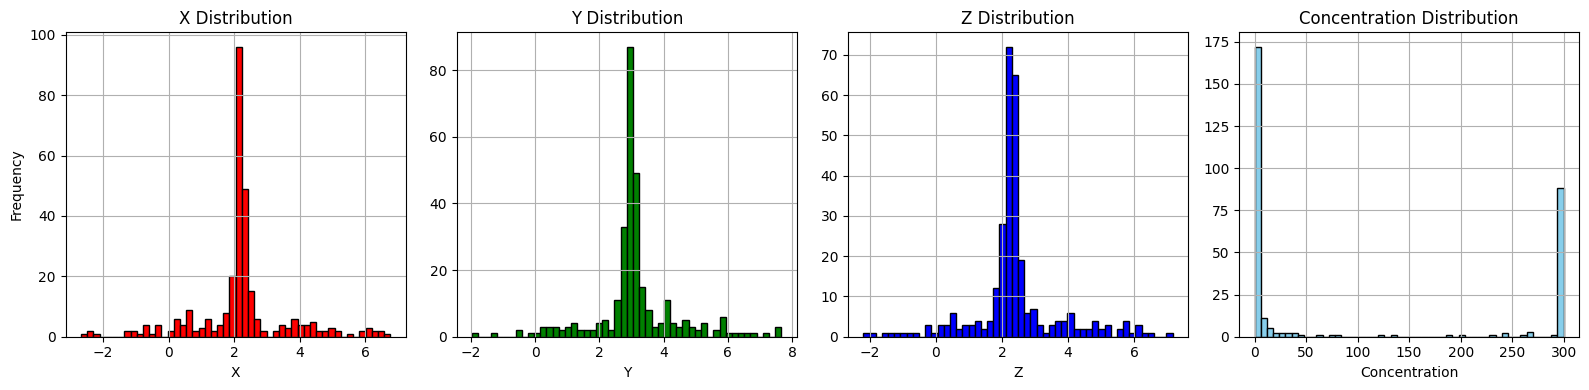

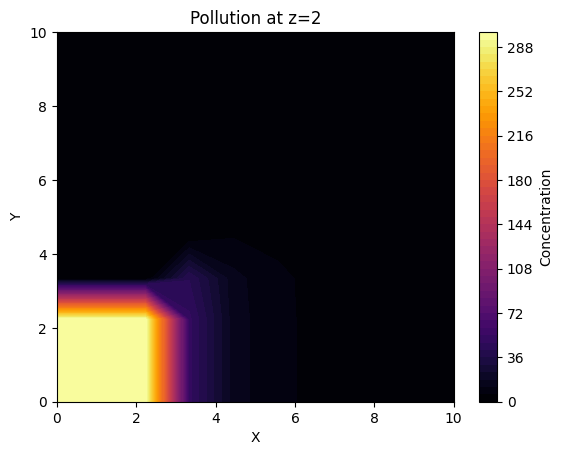

In [184]:
point_spread(X_train, Y_train, height_slice=2)

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_4d(X, Y, Z, C):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Normalize colors
    p = ax.scatter(X, Y, Z, c=C, cmap='viridis', marker='o', s=10)
    fig.colorbar(p, label='Concentration (4th dimension)')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('4D Plot: X, Y, Z + Concentration')
    plt.tight_layout()
    plt.show()


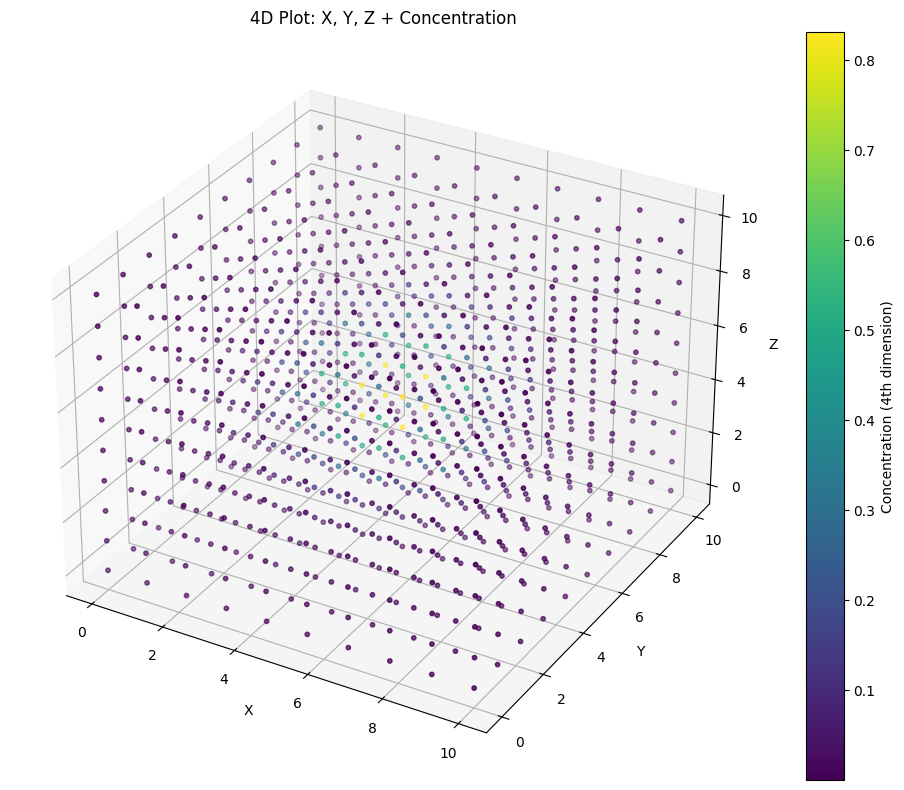

In [177]:

# Generate a simple 3D grid
x = np.linspace(0, 10, 10)
y = np.linspace(0, 10, 10)
z = np.linspace(0, 10, 10)

Xg, Yg, Zg = np.meshgrid(x, y, z)
X_flat = Xg.flatten()
Y_flat = Yg.flatten()
Z_flat = Zg.flatten()

# Example: 4th dimension = a 3D Gaussian (centered at 5,5,5)
C = np.exp(-((X_flat - 5)**2 + (Y_flat - 5)**2 + (Z_flat - 5)**2) / 5)

plot_4d(X_flat, Y_flat, Z_flat, C)